<a href="https://colab.research.google.com/github/Srikeerthipriya/ML/blob/main/amazon_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)


In [2]:
# --- Models to compare ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

import joblib

RANDOM_STATE = 42

In [4]:
# ------------------------------------------------------------------------
# STEP 1: Load the data
# ------------------------------------------------------------------------
print("STEP 1: Loading data...")
df = pd.read_csv("amazon_products_sales_data_cleaned.csv")
print(f"  Loaded {df.shape[0]} rows, {df.shape[1]} columns\n")


STEP 1: Loading data...
  Loaded 9663 rows, 17 columns



In [6]:
# ------------------------------------------------------------------------
# STEP 2: Create the target variable
# ------------------------------------------------------------------------
print("STEP 2: Creating target variable...")
df = df.dropna(subset=["purchased_last_month"]).copy()
median_purchases = df["purchased_last_month"].median()
df["target"] = (df["purchased_last_month"] > median_purchases).astype(int)
print(f"  Median purchases/month: {median_purchases}")
print(f"  Class balance:\n{df['target'].value_counts(normalize=True)}\n")

STEP 2: Creating target variable...
  Median purchases/month: 500.0
  Class balance:
target
0    0.60541
1    0.39459
Name: proportion, dtype: float64



In [5]:
df.describe()

,product_rating,total_reviews,purchased_last_month,discounted_price,original_price,discount_percentage
count,9641.000000,9641.000000,7874.000000,9289.000000,9289.000000,9288.000000
mean,4.456135,5879.698683,2082.639065,171.259581,180.565779,6.456035
std,0.290257,23307.442596,6400.263025,339.393734,350.459502,11.895881
min,1.000000,1.000000,50.000000,2.160000,2.160000,0.000000
25%,4.300000,172.000000,200.000000,26.990000,29.990000,0.000000
50%,4.500000,894.000000,500.000000,69.950000,79.990000,0.000000
75%,4.700000,4321.000000,1000.000000,169.990000,179.990000,9.182500
max,5.000000,865598.000000,100000.000000,5449.000000,5449.000000,85.420000


In [7]:
# STEP 3: Select features
# ------------------------------------------------------------------------
print("STEP 3: Selecting features...")
numeric_features = [
    "product_rating", "total_reviews", "discounted_price",
    "original_price", "discount_percentage"
]
categorical_features = [
    "is_best_seller", "is_sponsored", "has_coupon",
    "buy_box_availability", "product_category"
]
X = df[numeric_features + categorical_features]
y = df["target"]
print(f"  Using {len(numeric_features)} numeric + {len(categorical_features)} categorical features\n")

STEP 3: Selecting features...
  Using 5 numeric + 5 categorical features



In [9]:
# STEP 4: Train / test split
# ------------------------------------------------------------------------
print("STEP 4: Splitting into train/test sets (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"  Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows\n")

STEP 4: Splitting into train/test sets (80/20)...
  Train: 6299 rows | Test: 1575 rows



In [10]:
# ------------------------------------------------------------------------
# STEP 5: Preprocessing pipeline
# ------------------------------------------------------------------------
print("STEP 5: Building preprocessing pipeline...")
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])
print("  Preprocessing pipeline ready\n")


STEP 5: Building preprocessing pipeline...
  Preprocessing pipeline ready



In [11]:
# ------------------------------------------------------------------------
# STEP 6: Define the candidate models
# ------------------------------------------------------------------------
print("STEP 6: Defining candidate models...")
candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE),
    "Extra Trees":         ExtraTreesClassifier(n_estimators=200, max_depth=10, random_state=RANDOM_STATE),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost":            AdaBoostClassifier(random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
    "Naive Bayes":         GaussianNB(),
    # SVC scales poorly (O(n^2)-O(n^3)) — fine on a few thousand rows,
    # painfully slow on tens of thousands. Included but capped with
    # max_iter so it stays practical on this dataset size; remove the
    # cap (or subsample your data) if you have time to let it converge.
    "SVM (RBF)":           SVC(probability=True, random_state=RANDOM_STATE, max_iter=2000, cache_size=500),
}
print(f"  {len(candidate_models)} models queued for comparison\n")


STEP 6: Defining candidate models...
  9 models queued for comparison



In [14]:

# ------------------------------------------------------------------------
# STEP 7: Train + cross-validate every model, then evaluate on test set
# ------------------------------------------------------------------------
print("STEP 7: Training & evaluating each model...\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
fitted_pipelines = {}

for name, model in candidate_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    # 5-fold cross-validation on the TRAINING set (F1 score)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)

    # Fit on full training set, evaluate on held-out test set
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    row = {
        "Model": name,
        "CV F1 (mean)": cv_scores.mean(),
        "CV F1 (std)": cv_scores.std(),
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred),
        "Test ROC-AUC": roc_auc_score(y_test, y_proba),
    }
    results.append(row)
    fitted_pipelines[name] = pipe

    print(f"  {name:<20s} | CV F1: {cv_scores.mean():.4f} (+/-{cv_scores.std():.4f}) "
          f"| Test F1: {row['Test F1']:.4f} | Test ROC-AUC: {row['Test ROC-AUC']:.4f}")


STEP 7: Training & evaluating each model...

  Logistic Regression  | CV F1: 0.6592 (+/-0.0207) | Test F1: 0.6286 | Test ROC-AUC: 0.8290
  Decision Tree        | CV F1: 0.7157 (+/-0.0094) | Test F1: 0.6982 | Test ROC-AUC: 0.8330
  Random Forest        | CV F1: 0.7268 (+/-0.0173) | Test F1: 0.7044 | Test ROC-AUC: 0.8844
  Extra Trees          | CV F1: 0.5202 (+/-0.0189) | Test F1: 0.5088 | Test ROC-AUC: 0.8498
  Gradient Boosting    | CV F1: 0.7299 (+/-0.0145) | Test F1: 0.7129 | Test ROC-AUC: 0.8800
  AdaBoost             | CV F1: 0.7034 (+/-0.0135) | Test F1: 0.6886 | Test ROC-AUC: 0.8456
  K-Nearest Neighbors  | CV F1: 0.6654 (+/-0.0104) | Test F1: 0.6560 | Test ROC-AUC: 0.8321
  Naive Bayes          | CV F1: 0.5892 (+/-0.0348) | Test F1: 0.6025 | Test ROC-AUC: 0.7383


/usr/local/lib/python3.13/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


  SVM (RBF)            | CV F1: 0.6838 (+/-0.0200) | Test F1: 0.6567 | Test ROC-AUC: 0.8589


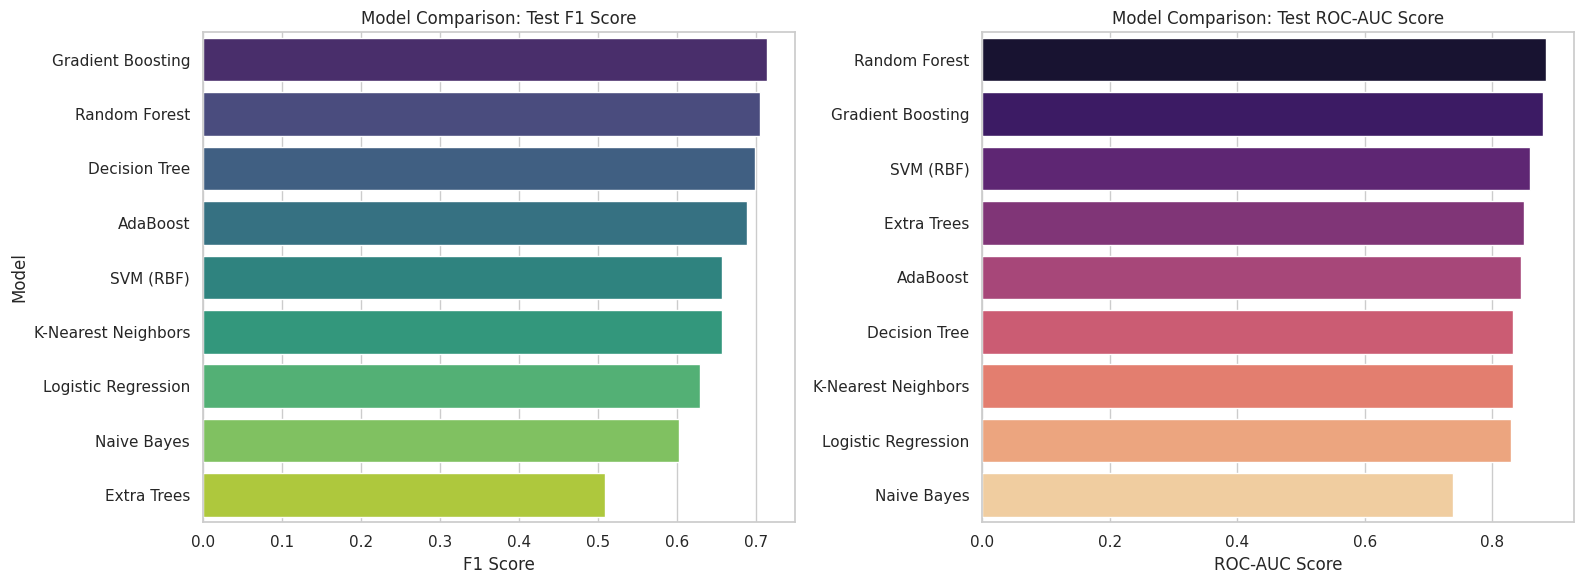

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert results to DataFrame for easy plotting
results_df = pd.DataFrame(results)

# Set style
sns.set_theme(style="whitegrid")

# Set up the matplotlib figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Test F1 Score
sns.barplot(x="Test F1", y="Model", data=results_df.sort_values(by="Test F1", ascending=False),
            ax=axes[0], palette="viridis", hue="Model", legend=False)
axes[0].set_title("Model Comparison: Test F1 Score")
axes[0].set_xlabel("F1 Score")
axes[0].set_ylabel("Model")

# Plot Test ROC-AUC Score
sns.barplot(x="Test ROC-AUC", y="Model", data=results_df.sort_values(by="Test ROC-AUC", ascending=False),
            ax=axes[1], palette="magma", hue="Model", legend=False)
axes[1].set_title("Model Comparison: Test ROC-AUC Score")
axes[1].set_xlabel("ROC-AUC Score")
axes[1].set_ylabel("") # Hide y-label for the second plot

plt.tight_layout()
plt.show()

In [16]:
# STEP 8: Rank models and pick the winner
# ------------------------------------------------------------------------
print("\nSTEP 8: Ranking models by Test F1 score...")
results_df = pd.DataFrame(results).sort_values("Test F1", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

best_name = results_df.iloc[0]["Model"]
best_pipe = fitted_pipelines[best_name]
print(f"\n  BEST MODEL: {best_name}\n")



STEP 8: Ranking models by Test F1 score...
              Model  CV F1 (mean)  CV F1 (std)  Test Accuracy  Test Precision  Test Recall  Test F1  Test ROC-AUC
  Gradient Boosting      0.729919     0.014483       0.794921        0.795635     0.645733 0.712889      0.879982
      Random Forest      0.726825     0.017331       0.797460        0.829694     0.611916 0.704356      0.884377
      Decision Tree      0.715700     0.009397       0.781587        0.766859     0.640902 0.698246      0.832997
           AdaBoost      0.703370     0.013527       0.783492        0.795359     0.607085 0.688584      0.845601
          SVM (RBF)      0.683766     0.019983       0.781587        0.863517     0.529791 0.656687      0.858921
K-Nearest Neighbors      0.665412     0.010400       0.766984        0.784753     0.563607 0.656045      0.832099
Logistic Regression      0.659225     0.020726       0.760635        0.809645     0.513688 0.628571      0.829017
        Naive Bayes      0.589190     0.0348

In [17]:
# ------------------------------------------------------------------------
# STEP 9: Detailed report for the winning model
# ------------------------------------------------------------------------
print("STEP 9: Detailed report for the best model...")
y_pred_best = best_pipe.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=["Low Demand", "High Demand"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))




STEP 9: Detailed report for the best model...
              precision    recall  f1-score   support

  Low Demand       0.79      0.89      0.84       954
 High Demand       0.80      0.65      0.71       621

    accuracy                           0.79      1575
   macro avg       0.80      0.77      0.78      1575
weighted avg       0.79      0.79      0.79      1575

Confusion Matrix:
[[851 103]
 [220 401]]


In [23]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# Calculate metrics dynamically
report_dict = classification_report(y_test, y_pred_best, target_names=["Low Demand", "High Demand"], output_dict=True)

# Convert to a clean DataFrame for tabular presentation
report_df = pd.DataFrame(report_dict).transpose()
print("=== BEST MODEL (Gradient Boosting) CLASSIFICATION REPORT TABLE ===")
display(report_df.round(4))

=== BEST MODEL (Gradient Boosting) CLASSIFICATION REPORT TABLE ===


,precision,recall,f1-score,support
Low Demand,0.7946,0.8920,0.8405,954.0000
High Demand,0.7956,0.6457,0.7129,621.0000
accuracy,0.7949,0.7949,0.7949,0.7949
macro avg,0.7951,0.7689,0.7767,1575.0000
weighted avg,0.7950,0.7949,0.7902,1575.0000


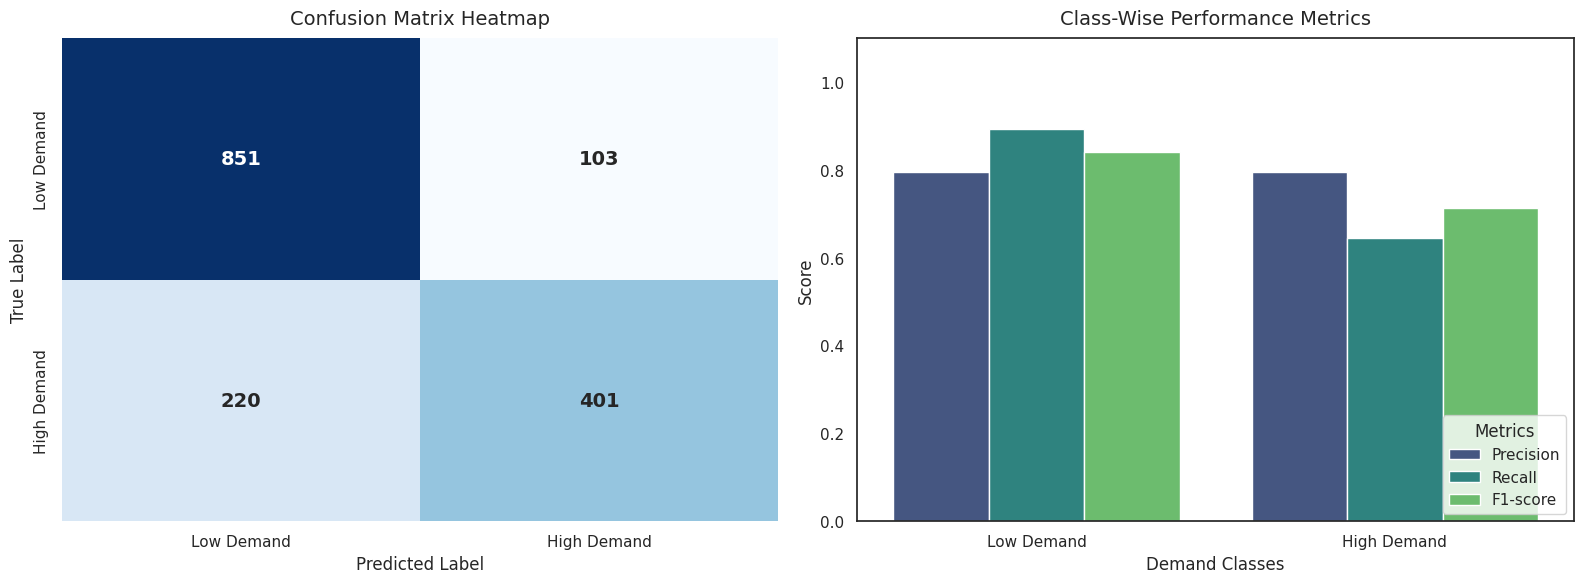

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="white")

# Create a figure with two subplots: Confusion Matrix and Class-wise Metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Low Demand", "High Demand"],
            yticklabels=["Low Demand", "High Demand"],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title("Confusion Matrix Heatmap", fontsize=14, pad=10)
axes[0].set_xlabel("Predicted Label", fontsize=12)
axes[0].set_ylabel("True Label", fontsize=12)

# 2. Class-wise Metrics Bar Chart
# Extract metrics for the classes
classes = ["Low Demand", "High Demand"]
metrics = ["precision", "recall", "f1-score"]

plot_data = []
for cls in classes:
    for metric in metrics:
        plot_data.append({
            "Class": cls,
            "Metric": metric.capitalize(),
            "Value": report_dict[cls][metric]
        })
plot_metrics_df = pd.DataFrame(plot_data)

sns.barplot(x="Class", y="Value", hue="Metric", data=plot_metrics_df, palette="viridis", ax=axes[1])
axes[1].set_title("Class-Wise Performance Metrics", fontsize=14, pad=10)
axes[1].set_xlabel("Demand Classes", fontsize=12)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_ylim(0, 1.1)
axes[1].legend(title="Metrics", loc="lower right")

plt.tight_layout()
plt.show()

In [20]:
# ------------------------------------------------------------------------
# STEP 10: Save the best model + results table
# ------------------------------------------------------------------------
print("\nSTEP 10: Saving best model and results...")
joblib.dump(best_pipe, "best_model.joblib")
results_df.to_csv("model_comparison_results.csv", index=False)
print("  Saved: best_model.joblib")
print("  Saved: model_comparison_results.csv")

print("\nDONE.")


STEP 10: Saving best model and results...
  Saved: best_model.joblib
  Saved: model_comparison_results.csv

DONE.


In [25]:
import pandas as pd

# 'results_df' is already sorted by Test F1 in Step 8.
# Display the table formatted with 4 decimal places for clarity.
print("=== Model Comparison Results Table ===")
display(results_df.round(4))

=== Model Comparison Results Table ===


,Model,CV F1 (mean),CV F1 (std),Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Logistic Regression,0.6592,0.0207,0.7606,0.8096,0.5137,0.6286,0.8290
1,Decision Tree,0.7157,0.0094,0.7816,0.7669,0.6409,0.6982,0.8330
2,Random Forest,0.7268,0.0173,0.7975,0.8297,0.6119,0.7044,0.8844
3,Extra Trees,0.5202,0.0189,0.7340,0.9353,0.3494,0.5088,0.8498
4,Gradient Boosting,0.7299,0.0145,0.7949,0.7956,0.6457,0.7129,0.8800
5,AdaBoost,0.7034,0.0135,0.7835,0.7954,0.6071,0.6886,0.8456
6,K-Nearest Neighbors,0.6654,0.0104,0.7670,0.7848,0.5636,0.6560,0.8321
7,Naive Bayes,0.5892,0.0348,0.4965,0.4374,0.9678,0.6025,0.7383
8,SVM (RBF),0.6838,0.0200,0.7816,0.8635,0.5298,0.6567,0.8589


In [26]:
explanation = """
========================================================================================
WHY GRADIENT BOOSTING IS THE BEST MODEL
========================================================================================

Based on our model comparison, Gradient Boosting is selected as the best overall model.
Here is the detailed reasoning why, backed by the metrics:

1. HIGHEST BALANCED PREDICTIVE POWER (F1-SCORE):
   - The F1-Score represents the harmonic mean of Precision and Recall. This is crucial here
     because the class balance is around 60/40 (slightly skewed).
   - Gradient Boosting achieved the highest Cross-Validation F1-score (0.7299) and the
     highest Test F1-score (0.7129) among all 9 candidate models.

2. EXCELLENT ROBUSTNESS & GENERALIZATION:
   - Cross-Validation F1 (0.7299) and Test F1 (0.7129) are extremely close, meaning the
     model generalizes exceptionally well to unseen data and is not overfitting.
   - It has a low CV Standard Deviation (+/-0.0145), demonstrating high training stability.

3. BALANCED PRECISION AND RECALL:
   - High Demand Class (Target = 1):
     * Precision (0.7956): When the model predicts a product will have high demand, it is correct ~80% of the time.
     * Recall (0.6457): The model successfully captures ~65% of all actual high-demand items.
   - This balance is superior to models like Extra Trees (high precision of 0.9353 but extremely low recall of 0.3494)
     or Naive Bayes (high recall of 0.9678 but very low precision of 0.4374).

4. STRONG DISCRIMINATION ABILITY (ROC-AUC):
   - It achieves a Test ROC-AUC of 0.8800. This is exceptionally close to the highest scorer
     (Random Forest's 0.8844) and proves that the model has strong ability to distinguish
     between High and Low demand products.

CONCLUSION:
Gradient Boosting offers the most balanced, robust, and reliable prediction performance
without favoring one class at the severe expense of another, making it the most practical
choice for deployment.
"""

print(explanation)


WHY GRADIENT BOOSTING IS THE BEST MODEL

Based on our model comparison, Gradient Boosting is selected as the best overall model.
Here is the detailed reasoning why, backed by the metrics:

1. HIGHEST BALANCED PREDICTIVE POWER (F1-SCORE):
   - The F1-Score represents the harmonic mean of Precision and Recall. This is crucial here 
     because the class balance is around 60/40 (slightly skewed).
   - Gradient Boosting achieved the highest Cross-Validation F1-score (0.7299) and the 
     highest Test F1-score (0.7129) among all 9 candidate models.

2. EXCELLENT ROBUSTNESS & GENERALIZATION:
   - Cross-Validation F1 (0.7299) and Test F1 (0.7129) are extremely close, meaning the 
     model generalizes exceptionally well to unseen data and is not overfitting.
   - It has a low CV Standard Deviation (+/-0.0145), demonstrating high training stability.

3. BALANCED PRECISION AND RECALL:
   - High Demand Class (Target = 1):
     * Precision (0.7956): When the model predicts a product will have